
# 📈 Backtester configurable — RSI + Bollinger + Volumen + MACD + ATR

Este notebook descarga datos con `yfinance` y permite probar una estrategia configurable con entre 1 y 5 herramientas.

Incluye:

- RSI
- Bollinger
- Volumen
- MACD
- ATR
- Capital inicial configurable
- Interés compuesto
- Ventana operativa independiente del rango gráfico
- Stop-loss por ATR o porcentaje fijo
- Tabla de operaciones
- Curva de capital
- Anulación de la última entrada si sigue abierta al terminar la ventana


In [12]:

# ================================================================
# ⚙️ CELDA 1 — CONFIGURACIÓN PRINCIPAL
# ================================================================
# 👉 MODIFICA NORMALMENTE SOLO ESTA CELDA
# ================================================================

# ------------------------------------------------
# 1️⃣ VALOR
# ------------------------------------------------
# DEJA ACTIVA SOLO UNA LÍNEA

TICKER = "META"        # Meta
# TICKER = "AMZN"      # Amazon
# TICKER = "NVDA"      # NVIDIA
# TICKER = "MSFT"      # Microsoft
# TICKER = "AAPL"      # Apple
# TICKER = "GOOGL"     # Alphabet
# TICKER = "AVGO"      # Broadcom
# TICKER = "TSLA"      # Tesla
# TICKER = "COST"      # Costco
# TICKER = "NFLX"      # Netflix


# ------------------------------------------------
# 2️⃣ RANGO TOTAL DEL GRÁFICO / DESCARGA
# ------------------------------------------------
# Formato AAAA-MM-DD
# Por defecto: 12 meses

FECHA_GRAFICA_INICIO = "2025-08-20"
FECHA_GRAFICA_FIN    = "2026-08-20"


# ------------------------------------------------
# 3️⃣ VENTANA OPERATIVA DEL BACKTEST
# ------------------------------------------------
# El algoritmo SOLO abrirá operaciones dentro de esta ventana.
#
# Ejemplo:
# FECHA_OPERATIVA_INICIO = "2026-01-01"
# FECHA_OPERATIVA_FIN    = "2026-04-01"

FECHA_OPERATIVA_INICIO = "2026-01-01"
FECHA_OPERATIVA_FIN    = "2026-06-01"


# ------------------------------------------------
# 4️⃣ CAPITAL
# ------------------------------------------------

CAPITAL_INICIAL = 10000.0
REINVERTIR_TODO = True


# ------------------------------------------------
# 5️⃣ ACTIVAR / DESACTIVAR HERRAMIENTAS
# ------------------------------------------------
# Puedes dejar activadas 1, 2, 3, 4 o las 5.

USAR_RSI       = True
USAR_BOLLINGER = True
USAR_VOLUMEN   = True
USAR_MACD      = False
USAR_ATR       = False


# ------------------------------------------------
# 6️⃣ MODO DE COMBINACIÓN
# ------------------------------------------------
#
# "TODAS"   -> deben cumplirse TODAS las herramientas activas
# "MINIMAS" -> basta con un número mínimo de confirmaciones

MODO_COMBINACION = "TODAS"

MIN_CONFIRMACIONES_ENTRADA = 2
MIN_CONFIRMACIONES_SALIDA  = 2


# ------------------------------------------------
# 7️⃣ RSI
# ------------------------------------------------

RSI_PERIODO = 14
RSI_SOBREVENTA = 35
RSI_SOBRECOMPRA = 70


# ------------------------------------------------
# 8️⃣ BOLLINGER
# ------------------------------------------------

BB_PERIODO = 20
BB_DESVIACIONES = 2.0


# ------------------------------------------------
# 9️⃣ VOLUMEN
# ------------------------------------------------

VOLUMEN_PERIODO = 20
VOLUMEN_MULTIPLICADOR = 1.20


# ------------------------------------------------
# 🔟 MACD
# ------------------------------------------------

MACD_RAPIDA = 12
MACD_LENTA  = 26
MACD_SIGNAL = 9


# ------------------------------------------------
# 1️⃣1️⃣ ATR / STOP
# ------------------------------------------------

ATR_PERIODO = 14
ATR_MULT_STOP = 2.0

# True = el stop puede ir subiendo, nunca bajando
ATR_TRAILING = True

# ATR también puede actuar como filtro de volatilidad
ATR_FILTRO_PERIODO = 20
ATR_FILTRO_MULT = 0.80


# ------------------------------------------------
# 1️⃣2️⃣ STOP SI ATR ESTÁ DESACTIVADO
# ------------------------------------------------

STOP_FIJO_PCT = 5.0


# ------------------------------------------------
# 1️⃣3️⃣ COSTES
# ------------------------------------------------
# 0.10 significa 0,10 %

COMISION_PCT = 0.0
SLIPPAGE_PCT = 0.0


# ------------------------------------------------
# 1️⃣4️⃣ SALIDA TÉCNICA
# ------------------------------------------------

USAR_SENAL_SALIDA = True


herramientas = {
    "RSI": USAR_RSI,
    "Bollinger": USAR_BOLLINGER,
    "Volumen": USAR_VOLUMEN,
    "MACD": USAR_MACD,
    "ATR": USAR_ATR,
}

activas = [k for k, v in herramientas.items() if v]

if not activas:
    raise ValueError("Debes activar al menos una herramienta.")

print("=" * 70)
print("📊 CONFIGURACIÓN DEL BACKTEST")
print("=" * 70)
print(f"Ticker:                {TICKER}")
print(f"Gráfico:               {FECHA_GRAFICA_INICIO} → {FECHA_GRAFICA_FIN}")
print(f"Ventana operativa:     {FECHA_OPERATIVA_INICIO} → {FECHA_OPERATIVA_FIN}")
print(f"Capital inicial:       ${CAPITAL_INICIAL:,.2f}")
print(f"Herramientas activas:  {', '.join(activas)}")
print(f"Modo combinación:      {MODO_COMBINACION}")
print("=" * 70)


📊 CONFIGURACIÓN DEL BACKTEST
Ticker:                META
Gráfico:               2025-08-20 → 2026-08-20
Ventana operativa:     2026-01-01 → 2026-06-01
Capital inicial:       $10,000.00
Herramientas activas:  RSI, Bollinger, Volumen
Modo combinación:      TODAS


In [13]:

# ================================================================
# 📦 CELDA 2 — LIBRERÍAS
# ================================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

print("✅ Librerías cargadas")


✅ Librerías cargadas


In [14]:

# ================================================================
# 📥 CELDA 3 — DESCARGAR HISTÓRICO
# ================================================================

print(f"📥 Descargando {TICKER}...")

df = yf.download(
    TICKER,
    start=FECHA_GRAFICA_INICIO,
    end=FECHA_GRAFICA_FIN,
    interval="1d",
    auto_adjust=False,
    progress=False
)

if df.empty:
    raise ValueError("No se han descargado datos. Revisa ticker y fechas.")

df = df.reset_index()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]

columnas = ["Date", "Open", "High", "Low", "Close", "Volume"]
df = df[[x for x in columnas if x in df.columns]].copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

print(f"✅ {len(df)} sesiones descargadas")
print(f"Desde: {df['Date'].min().date()}")
print(f"Hasta: {df['Date'].max().date()}")

display(df.tail())


📥 Descargando META...
✅ 251 sesiones descargadas
Desde: 2025-08-20
Hasta: 2026-08-19


,Date,Open,High,Low,Close,Volume
246,2026-08-13,580.710022,595.849976,579.390015,594.969971,11164200
247,2026-08-14,596.979980,601.859985,589.289978,589.849976,8758000
248,2026-08-17,589.750000,590.239990,564.750000,568.969971,17225600
249,2026-08-18,557.479980,560.659973,543.210022,543.669983,27094900
250,2026-08-19,541.340027,554.059998,537.280029,546.030029,16348636


In [15]:

# ================================================================
# 🧮 CELDA 4 — CALCULAR INDICADORES
# ================================================================

data = df.copy()

# RSI (Wilder)
delta = data["Close"].diff()
ganancia = delta.clip(lower=0)
perdida = -delta.clip(upper=0)

avg_gain = ganancia.ewm(
    alpha=1/RSI_PERIODO,
    adjust=False,
    min_periods=RSI_PERIODO
).mean()

avg_loss = perdida.ewm(
    alpha=1/RSI_PERIODO,
    adjust=False,
    min_periods=RSI_PERIODO
).mean()

rs = avg_gain / avg_loss.replace(0, np.nan)
data["RSI"] = 100 - (100 / (1 + rs))

# Bollinger
data["BB_Media"] = data["Close"].rolling(BB_PERIODO).mean()
bb_std = data["Close"].rolling(BB_PERIODO).std(ddof=0)
data["BB_Sup"] = data["BB_Media"] + BB_DESVIACIONES * bb_std
data["BB_Inf"] = data["BB_Media"] - BB_DESVIACIONES * bb_std

# Volumen
data["Vol_Media"] = data["Volume"].rolling(VOLUMEN_PERIODO).mean()

# MACD
ema_rapida = data["Close"].ewm(span=MACD_RAPIDA, adjust=False).mean()
ema_lenta = data["Close"].ewm(span=MACD_LENTA, adjust=False).mean()

data["MACD"] = ema_rapida - ema_lenta
data["MACD_Signal"] = data["MACD"].ewm(span=MACD_SIGNAL, adjust=False).mean()
data["MACD_Hist"] = data["MACD"] - data["MACD_Signal"]

# ATR
prev_close = data["Close"].shift(1)

tr1 = data["High"] - data["Low"]
tr2 = (data["High"] - prev_close).abs()
tr3 = (data["Low"] - prev_close).abs()

true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

data["ATR"] = true_range.ewm(
    alpha=1/ATR_PERIODO,
    adjust=False,
    min_periods=ATR_PERIODO
).mean()

data["ATR_Pct"] = (data["ATR"] / data["Close"]) * 100
data["ATR_Pct_Media"] = data["ATR_Pct"].rolling(ATR_FILTRO_PERIODO).mean()

print("✅ Indicadores calculados")

display(
    data[
        ["Date", "Close", "RSI", "BB_Inf", "BB_Sup",
         "Volume", "Vol_Media", "MACD", "MACD_Signal", "ATR", "ATR_Pct"]
    ].tail(10)
)


✅ Indicadores calculados


,Date,Close,RSI,BB_Inf,BB_Sup,Volume,Vol_Media,MACD,MACD_Signal,ATR,ATR_Pct
241,2026-08-06,589.900024,47.004349,537.894359,694.349636,11811500,18719170.0,-8.164710,-4.446323,23.997983,4.068144
242,2026-08-07,592.099976,47.668632,537.354228,687.178761,11250300,17251240.0,-7.540675,-5.065193,23.220984,3.921801
243,2026-08-10,594.919983,48.558747,536.799045,681.552945,14967300,17007570.0,-6.740867,-5.400328,22.718056,3.818674
244,2026-08-11,599.119995,49.924873,537.652427,674.507564,13146900,16827505.0,-5.702374,-5.460737,22.454621,3.747934
245,2026-08-12,578.849976,43.869628,541.009220,660.904769,16186900,16686680.0,-6.440737,-5.656737,22.728575,3.926505
246,2026-08-13,594.969971,49.151505,545.095810,649.861178,11164200,16454090.0,-5.659903,-5.657370,22.319391,3.751347
247,2026-08-14,589.849976,47.618802,547.204891,642.136094,8758000,15778595.0,-5.392070,-5.604310,21.623007,3.665849
248,2026-08-17,568.969971,41.882876,548.375185,633.277799,17225600,16128615.0,-6.786423,-5.840733,21.899220,3.848924
249,2026-08-18,543.669983,36.193891,546.005799,625.633185,27094900,17026335.0,-9.819759,-6.636538,22.174986,4.078759
250,2026-08-19,546.030029,37.052824,543.110704,620.414284,16348636,17292786.8,-11.896133,-7.688457,21.789628,3.990555


In [16]:

# ================================================================
# 🚦 CELDA 5 — SEÑALES DE ENTRADA Y SALIDA
# ================================================================

sig = data.copy()

# RSI
sig["RSI_Entrada"] = (
    (sig["RSI"].shift(1) <= RSI_SOBREVENTA) &
    (sig["RSI"] > RSI_SOBREVENTA)
)

sig["RSI_Salida"] = sig["RSI"] >= RSI_SOBRECOMPRA

# Bollinger
sig["BOLL_Entrada"] = (
    (sig["Close"].shift(1) <= sig["BB_Inf"].shift(1)) &
    (sig["Close"] > sig["BB_Inf"])
)

sig["BOLL_Salida"] = sig["Close"] >= sig["BB_Sup"]

# Volumen
sig["VOL_Entrada"] = (
    (sig["Volume"] >= sig["Vol_Media"] * VOLUMEN_MULTIPLICADOR) &
    (sig["Close"] > sig["Open"])
)

sig["VOL_Salida"] = (
    (sig["Volume"] >= sig["Vol_Media"] * VOLUMEN_MULTIPLICADOR) &
    (sig["Close"] < sig["Open"])
)

# MACD
sig["MACD_Entrada"] = (
    (sig["MACD"].shift(1) <= sig["MACD_Signal"].shift(1)) &
    (sig["MACD"] > sig["MACD_Signal"])
)

sig["MACD_Salida"] = (
    (sig["MACD"].shift(1) >= sig["MACD_Signal"].shift(1)) &
    (sig["MACD"] < sig["MACD_Signal"])
)

# ATR
# ATR no da dirección por sí solo.
# Aquí funciona como filtro de volatilidad y para el stop.
sig["ATR_Entrada"] = (
    sig["ATR_Pct"] >= sig["ATR_Pct_Media"] * ATR_FILTRO_MULT
)

sig["ATR_Salida"] = (
    (sig["Close"] < sig["Close"].shift(1)) &
    (sig["ATR_Pct"] >= sig["ATR_Pct_Media"])
)

entrada_cols = []
salida_cols = []

if USAR_RSI:
    entrada_cols.append("RSI_Entrada")
    salida_cols.append("RSI_Salida")

if USAR_BOLLINGER:
    entrada_cols.append("BOLL_Entrada")
    salida_cols.append("BOLL_Salida")

if USAR_VOLUMEN:
    entrada_cols.append("VOL_Entrada")
    salida_cols.append("VOL_Salida")

if USAR_MACD:
    entrada_cols.append("MACD_Entrada")
    salida_cols.append("MACD_Salida")

if USAR_ATR:
    entrada_cols.append("ATR_Entrada")
    salida_cols.append("ATR_Salida")

sig["Confirmaciones_Entrada"] = sig[entrada_cols].sum(axis=1)
sig["Confirmaciones_Salida"] = sig[salida_cols].sum(axis=1)

n_activas = len(entrada_cols)

if MODO_COMBINACION.upper() == "TODAS":
    sig["Entrada_OK"] = sig["Confirmaciones_Entrada"] >= n_activas
    sig["Salida_OK"] = sig["Confirmaciones_Salida"] >= n_activas

elif MODO_COMBINACION.upper() == "MINIMAS":
    min_ent = min(max(1, MIN_CONFIRMACIONES_ENTRADA), n_activas)
    min_sal = min(max(1, MIN_CONFIRMACIONES_SALIDA), n_activas)

    sig["Entrada_OK"] = sig["Confirmaciones_Entrada"] >= min_ent
    sig["Salida_OK"] = sig["Confirmaciones_Salida"] >= min_sal

else:
    raise ValueError("MODO_COMBINACION debe ser 'TODAS' o 'MINIMAS'.")

print(f"✅ Señales preparadas con {n_activas} herramientas activas")
print("Entrada:", entrada_cols)
print("Salida: ", salida_cols)


✅ Señales preparadas con 3 herramientas activas
Entrada: ['RSI_Entrada', 'BOLL_Entrada', 'VOL_Entrada']
Salida:  ['RSI_Salida', 'BOLL_Salida', 'VOL_Salida']


In [17]:

# ================================================================
# 🧪 CELDA 6 — MOTOR DE BACKTEST
# ================================================================
#
# REGLAS:
#
# - señal detectada al cierre de hoy
# - entrada/salida técnica en la apertura de mañana
# - stop comprobado con el mínimo diario
# - si la última operación queda abierta al final de la ventana,
#   se ANULA y no afecta al capital
# ================================================================

fecha_ini = pd.Timestamp(FECHA_OPERATIVA_INICIO)
fecha_fin = pd.Timestamp(FECHA_OPERATIVA_FIN)

if fecha_ini >= fecha_fin:
    raise ValueError("La fecha inicial debe ser anterior a la final.")

capital = float(CAPITAL_INICIAL)

en_posicion = False
entrada = {}
operaciones = []
operacion_anulada = None

for i in range(1, len(sig) - 1):

    ayer = sig.iloc[i - 1]
    hoy = sig.iloc[i]
    manana = sig.iloc[i + 1]

    fecha_hoy = hoy["Date"]
    fecha_manana = manana["Date"]

    # ------------------------------------------------------------
    # POSICIÓN ABIERTA
    # ------------------------------------------------------------
    if en_posicion:

        # Actualizar trailing ATR con información ya conocida
        if USAR_ATR and ATR_TRAILING and not pd.isna(ayer["ATR"]):

            nuevo_stop = ayer["Close"] - ATR_MULT_STOP * ayer["ATR"]

            entrada["stop_actual"] = max(
                entrada["stop_actual"],
                nuevo_stop
            )

        # STOP intradía
        if hoy["Low"] <= entrada["stop_actual"]:

            precio_salida = entrada["stop_actual"] * (1 - SLIPPAGE_PCT / 100)

            importe_salida = entrada["acciones"] * precio_salida
            coste_salida = importe_salida * (COMISION_PCT / 100)

            capital_final_op = importe_salida - coste_salida

            ganancia_pct = (
                capital_final_op / entrada["capital_invertido_neto"] - 1
            ) * 100

            capital = capital_final_op

            operaciones.append({
                "Entrada": entrada["fecha"],
                "Precio entrada": entrada["precio"],
                "Salida": fecha_hoy,
                "Precio salida": precio_salida,
                "Motivo salida": "STOP",
                "Ganancia %": ganancia_pct,
                "Capital antes": entrada["capital_antes"],
                "Capital después": capital,
                "Confirmaciones entrada": entrada["confirmaciones"],
                "Stop inicial": entrada["stop_inicial"]
            })

            en_posicion = False
            entrada = {}
            continue

        # SALIDA por señal hoy -> apertura mañana
        if (
            USAR_SENAL_SALIDA
            and bool(hoy["Salida_OK"])
            and fecha_manana <= fecha_fin
        ):

            precio_salida = manana["Open"] * (1 - SLIPPAGE_PCT / 100)

            importe_salida = entrada["acciones"] * precio_salida
            coste_salida = importe_salida * (COMISION_PCT / 100)

            capital_final_op = importe_salida - coste_salida

            ganancia_pct = (
                capital_final_op / entrada["capital_invertido_neto"] - 1
            ) * 100

            capital = capital_final_op

            operaciones.append({
                "Entrada": entrada["fecha"],
                "Precio entrada": entrada["precio"],
                "Salida": fecha_manana,
                "Precio salida": precio_salida,
                "Motivo salida": "SEÑAL",
                "Ganancia %": ganancia_pct,
                "Capital antes": entrada["capital_antes"],
                "Capital después": capital,
                "Confirmaciones entrada": entrada["confirmaciones"],
                "Stop inicial": entrada["stop_inicial"]
            })

            en_posicion = False
            entrada = {}

        continue

    # ------------------------------------------------------------
    # EN LÍQUIDO: buscar nueva entrada
    # ------------------------------------------------------------

    puede_entrar_manana = (
        fecha_manana >= fecha_ini
        and fecha_manana <= fecha_fin
    )

    if bool(hoy["Entrada_OK"]) and puede_entrar_manana:

        if USAR_ATR and pd.isna(hoy["ATR"]):
            continue

        precio_entrada = manana["Open"] * (1 + SLIPPAGE_PCT / 100)

        capital_para_operar = (
            capital if REINVERTIR_TODO else CAPITAL_INICIAL
        )

        factor_comision = 1 + COMISION_PCT / 100
        acciones = capital_para_operar / (precio_entrada * factor_comision)

        importe_compra = acciones * precio_entrada
        coste_compra = importe_compra * (COMISION_PCT / 100)

        capital_invertido_neto = importe_compra + coste_compra

        if USAR_ATR:
            stop_inicial = precio_entrada - ATR_MULT_STOP * hoy["ATR"]
        else:
            stop_inicial = precio_entrada * (1 - STOP_FIJO_PCT / 100)

        entrada = {
            "fecha": fecha_manana,
            "precio": precio_entrada,
            "acciones": acciones,
            "capital_antes": capital,
            "capital_invertido_neto": capital_invertido_neto,
            "confirmaciones": int(hoy["Confirmaciones_Entrada"]),
            "stop_inicial": stop_inicial,
            "stop_actual": stop_inicial
        }

        en_posicion = True


# ------------------------------------------------
# REGLA ESPECIAL:
# Si queda una operación abierta al finalizar la ventana,
# esa operación se anula y recuperamos el capital previo.
# ------------------------------------------------

if en_posicion:

    operacion_anulada = {
        "Entrada anulada": entrada["fecha"],
        "Precio entrada": entrada["precio"],
        "Motivo": "Seguía abierta al finalizar la ventana operativa"
    }

    capital = entrada["capital_antes"]

    en_posicion = False
    entrada = {}

ops = pd.DataFrame(operaciones)

print("=" * 80)
print("✅ BACKTEST TERMINADO")
print("=" * 80)
print(f"Capital inicial: ${CAPITAL_INICIAL:,.2f}")
print(f"Capital final:   ${capital:,.2f}")
print(f"Rentabilidad:    {(capital / CAPITAL_INICIAL - 1) * 100:+.2f}%")
print(f"Operaciones:     {len(ops)}")

if operacion_anulada:
    print()
    print("⚠️ OPERACIÓN FINAL ANULADA")
    print(f"Entrada: {operacion_anulada['Entrada anulada'].date()}")
    print(f"Precio:  ${operacion_anulada['Precio entrada']:.2f}")


✅ BACKTEST TERMINADO
Capital inicial: $10,000.00
Capital final:   $10,000.00
Rentabilidad:    +0.00%
Operaciones:     0


In [18]:

# ================================================================
# 📋 CELDA 7 — TABLA DE OPERACIONES
# ================================================================

if ops.empty:

    print("No se completó ninguna operación dentro de la ventana.")

else:

    tabla = ops.copy()

    for col in ["Precio entrada", "Precio salida", "Stop inicial"]:
        tabla[col] = tabla[col].map(lambda x: f"${x:,.2f}")

    tabla["Ganancia %"] = tabla["Ganancia %"].map(lambda x: f"{x:+.2f}%")
    tabla["Capital antes"] = tabla["Capital antes"].map(lambda x: f"${x:,.2f}")
    tabla["Capital después"] = tabla["Capital después"].map(lambda x: f"${x:,.2f}")

    display(tabla)

if operacion_anulada:

    print()
    print("Entrada anulada por quedar abierta al final de la ventana:")
    display(pd.DataFrame([operacion_anulada]))


No se completó ninguna operación dentro de la ventana.


In [19]:

# ================================================================
# 📊 CELDA 8 — RESUMEN ESTADÍSTICO
# ================================================================

if ops.empty:

    print("Sin operaciones cerradas para calcular estadísticas.")

else:

    positivas = (ops["Ganancia %"] > 0).sum()
    negativas = (ops["Ganancia %"] <= 0).sum()

    acierto = positivas / len(ops) * 100
    mejor = ops["Ganancia %"].max()
    peor = ops["Ganancia %"].min()
    media = ops["Ganancia %"].mean()

    equity = pd.Series(
        [CAPITAL_INICIAL] + ops["Capital después"].tolist(),
        dtype=float
    )

    max_acum = equity.cummax()
    drawdown = (equity / max_acum - 1) * 100
    max_drawdown = drawdown.min()

    print("=" * 65)
    print(f"📊 RESULTADOS — {TICKER}")
    print("=" * 65)
    print(f"Capital inicial:       ${CAPITAL_INICIAL:,.2f}")
    print(f"Capital final:         ${capital:,.2f}")
    print(f"Rentabilidad total:    {(capital/CAPITAL_INICIAL - 1)*100:+.2f}%")
    print(f"Operaciones cerradas:  {len(ops)}")
    print(f"Ganadoras:             {positivas}")
    print(f"Perdedoras:            {negativas}")
    print(f"Acierto:               {acierto:.1f}%")
    print(f"Ganancia media/op.:    {media:+.2f}%")
    print(f"Mejor operación:       {mejor:+.2f}%")
    print(f"Peor operación:        {peor:+.2f}%")
    print(f"Drawdown aprox.:       {max_drawdown:.2f}%")
    print("=" * 65)


Sin operaciones cerradas para calcular estadísticas.


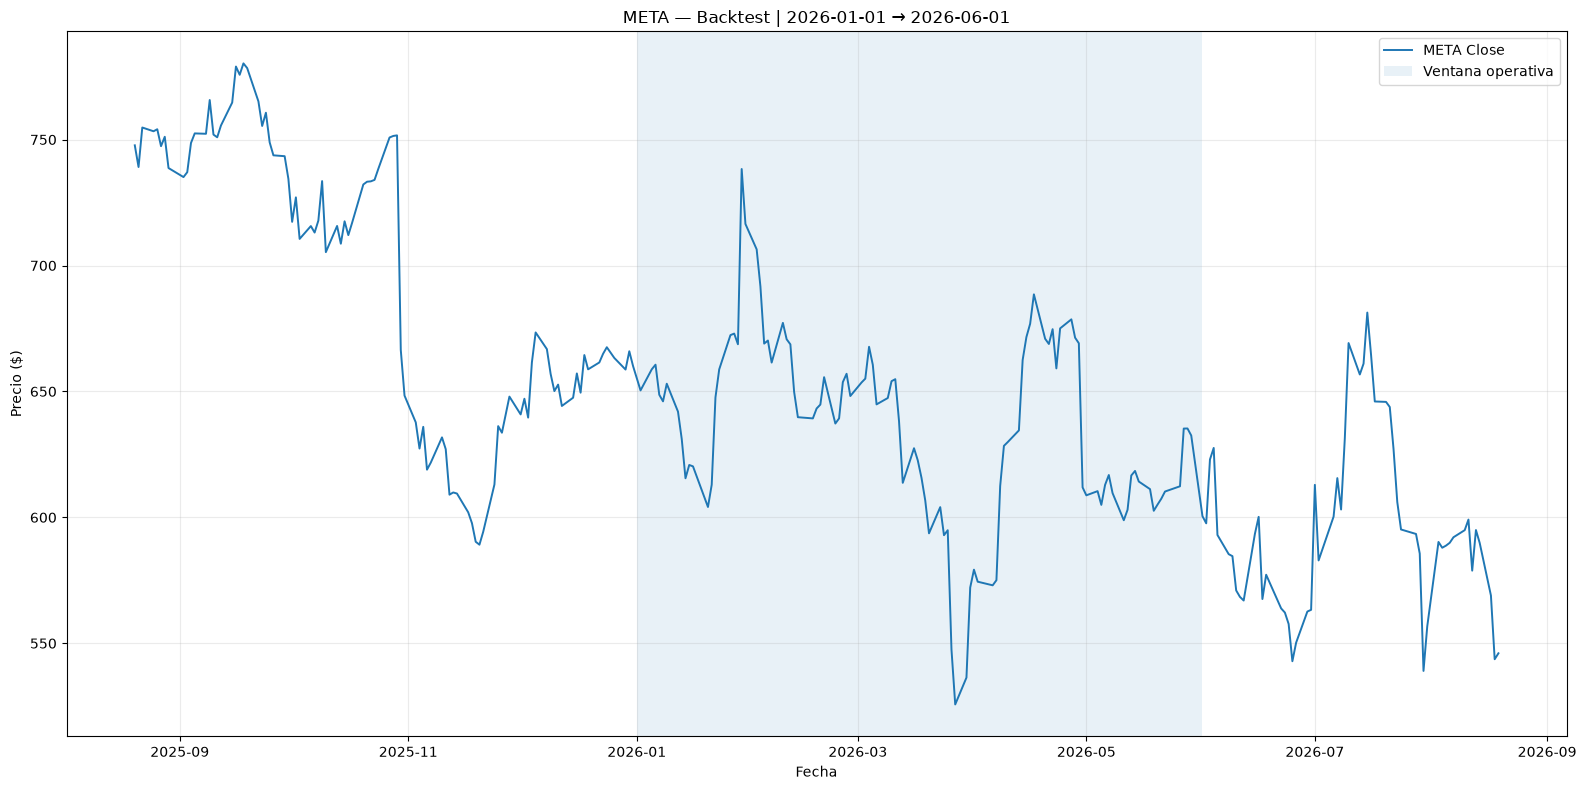

In [20]:

# ================================================================
# 📈 CELDA 9 — GRÁFICA GENERAL + ENTRADAS/SALIDAS
# ================================================================

plt.figure(figsize=(16, 8))

plt.plot(
    sig["Date"],
    sig["Close"],
    linewidth=1.4,
    label=f"{TICKER} Close"
)

plt.axvspan(
    pd.Timestamp(FECHA_OPERATIVA_INICIO),
    pd.Timestamp(FECHA_OPERATIVA_FIN),
    alpha=0.10,
    label="Ventana operativa"
)

if not ops.empty:

    plt.scatter(
        ops["Entrada"],
        ops["Precio entrada"],
        marker="^",
        s=90,
        label="Entrada",
        zorder=5
    )

    plt.scatter(
        ops["Salida"],
        ops["Precio salida"],
        marker="v",
        s=90,
        label="Salida",
        zorder=5
    )

if operacion_anulada:

    plt.scatter(
        [operacion_anulada["Entrada anulada"]],
        [operacion_anulada["Precio entrada"]],
        marker="x",
        s=120,
        label="Entrada anulada",
        zorder=6
    )

plt.title(
    f"{TICKER} — Backtest | "
    f"{FECHA_OPERATIVA_INICIO} → {FECHA_OPERATIVA_FIN}"
)

plt.xlabel("Fecha")
plt.ylabel("Precio ($)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [21]:

# ================================================================
# 📉 CELDA 10 — CURVA DE CAPITAL
# ================================================================

if ops.empty:

    print("No hay operaciones cerradas para dibujar la curva de capital.")

else:

    fechas_equity = [pd.Timestamp(FECHA_OPERATIVA_INICIO)] + ops["Salida"].tolist()
    valores_equity = [CAPITAL_INICIAL] + ops["Capital después"].tolist()

    plt.figure(figsize=(14, 6))

    plt.plot(
        fechas_equity,
        valores_equity,
        marker="o"
    )

    plt.title(f"{TICKER} — Evolución del capital")
    plt.xlabel("Fecha")
    plt.ylabel("Capital ($)")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


No hay operaciones cerradas para dibujar la curva de capital.


In [22]:

# ================================================================
# 💾 CELDA 11 — GUARDAR RESULTADOS EN CSV
# ================================================================

if ops.empty:

    print("No hay operaciones cerradas para guardar.")

else:

    nombre = (
        f"BACKTEST_{TICKER}_"
        f"{FECHA_OPERATIVA_INICIO}_"
        f"{FECHA_OPERATIVA_FIN}.csv"
    )

    ops.to_csv(nombre, index=False)

    print(f"✅ Resultados guardados en: {nombre}")


No hay operaciones cerradas para guardar.



## Notas importantes

- **RSI** busca recuperación desde sobreventa.
- **Bollinger** busca reentrada desde la banda inferior y salida en la superior.
- **Volumen** actúa como confirmación de actividad.
- **MACD** usa cruces de línea MACD y señal.
- **ATR** mide volatilidad; se usa principalmente para adaptar el stop-loss.

### Combinar indicadores

Con:

```python
MODO_COMBINACION = "TODAS"
```

deben cumplirse todas las herramientas activas.

Con:

```python
MODO_COMBINACION = "MINIMAS"
MIN_CONFIRMACIONES_ENTRADA = 2
```

basta con 2 confirmaciones.

No siempre más indicadores significa mejor sistema: exigir demasiadas condiciones puede reducir muchísimo el número de operaciones.
